## Modelo K-Means

El objetivo de este modelo es la segmentación de clientes de e-commerce según su comportamiento de compra usando K-Means.

#### Librerías utilizadas

Las librerías utilizadas en este modelo son:

- Pandas: para la manipulación de datos.
- Matplotlib: para la visualización de datos.
- Sklearn: para la implementación del modelo K-Means y la evaluación de su rendimiento.

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

#### Carga de datos

Se carga el csv previamente transformado para obtener las características claves de los clientes.

In [42]:
df = pd.read_csv('../../output/clustering/data_transformado_clustering.csv')
print(f"Shape: {df.shape}")
print(df.head())

Shape: (3592, 5)
   CustomerID  Transacciones  ProductosDistintos  GastoTotal  FrecuenciaCompra
0       12348       0.285714            0.030864    0.022193          0.285714
1       12349       0.000000            0.401235    0.460020          0.000000
2       12350       0.000000            0.092593    0.076723          0.000000
3       12352       0.857143            0.339506    0.498384          0.857143
4       12353       0.000000            0.018519    0.029790          0.000000


#### Preparación de los datos

Se utilizan las columnas de características para el clustering, eliminando la columna 'CustomerID' que no aporta información relevante para la segmentación. Luego, se escala la matriz de características utilizando StandardScaler para mejorar el rendimiento del modelo K-Means.

In [43]:
X = df.drop('CustomerID', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Shape escalado: {X_scaled.shape}")

Shape escalado: (3592, 4)


#### Número óptimo de clusters

Para intentar buscar los valores más correctos de K, se utiliza el método del "codo" y se visualiza el Silhouette Score para cada valor de K. Se obtiene que los valores con mayor Silhouette Score son 2 y 4, pero el codo se aprecia mejor en K=4, por lo tanto será el número de clusters elegido para el modelo K-Means.

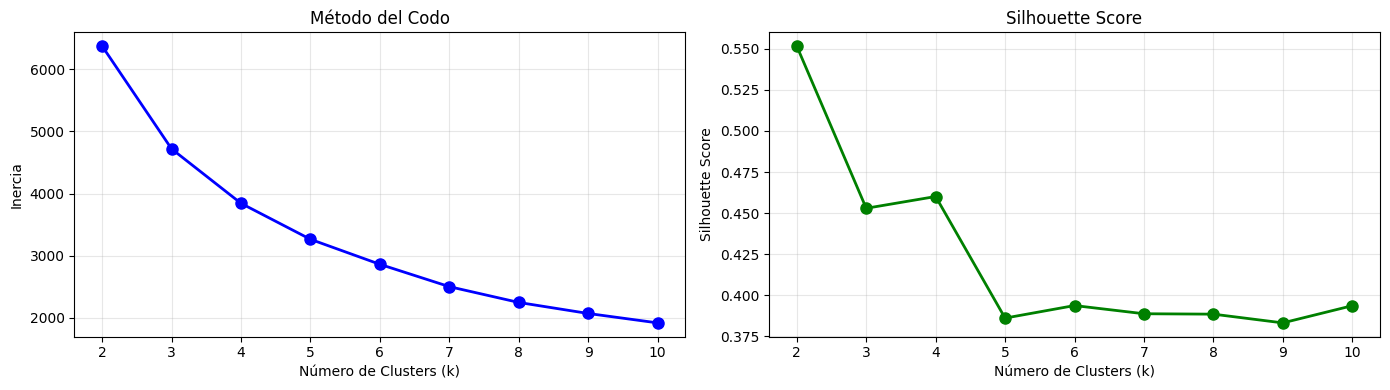

k=2: Silhouette Score = 0.5516
k=3: Silhouette Score = 0.4529
k=4: Silhouette Score = 0.4601
k=5: Silhouette Score = 0.3861
k=6: Silhouette Score = 0.3937
k=7: Silhouette Score = 0.3887
k=8: Silhouette Score = 0.3885
k=9: Silhouette Score = 0.3831
k=10: Silhouette Score = 0.3936


In [44]:
inertias, silhouette_scores = [], []
K_range = range(2, 11)

for k in K_range:
  km = KMeans(n_clusters=k, random_state=42, n_init=10)
  km.fit(X_scaled)
  inertias.append(km.inertia_)
  silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for k, score in zip(K_range, silhouette_scores):
  print(f"k={k}: Silhouette Score = {score:.4f}")

#### Entrenamiento del modelo K-Means

Entrenando al modelo K-Means con K=4 y se aprecia la cantidad de clientes que hay en cada cluster. Hay una mayoría de distribución en el cluster 1 y el resto de clusteres se reparten de forma más equilibrada. Esto nos indica que el cluster 1 representa un segmento de clientes más grande, mientras que los otros clusteres representan segmentos más pequeños pero distintos entre sí. Es importante analizar las características de cada cluster para entender mejor el comportamiento de los clientes en cada segmento y poder tomar decisiones informadas para estrategias de marketing o personalización.

In [45]:
k_optima = 4
kmeans_final = KMeans(n_clusters=k_optima, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)
df['Cluster'] = clusters

print(f"Modelo entrenado con {k_optima} clusters")
print(df['Cluster'].value_counts().sort_index().to_string())

Modelo entrenado con 4 clusters
Cluster
0     417
1    2054
2     615
3     506


#### Evaluación del modelo

Se comprueban las métricas de Silhouette Score y Davies-Bouldin Index para evaluar la calidad del clustering en K=4. Se obtiene un buen resultado con un Silhouette Score esperado de 0.46 y un Davies-Bouldin Index de 1.03. Estos resultados indican que los clusters están bien definidos y separados.

In [46]:
silhouette_avg = silhouette_score(X_scaled, clusters)
davies_bouldin = davies_bouldin_score(X_scaled, clusters)

print(f"Silhouette Score:        {silhouette_avg:.4f}")
print(f"Davies-Bouldin Index:    {davies_bouldin:.4f}")

Silhouette Score:        0.4601
Davies-Bouldin Index:    1.0322


#### Perfiles de clusters

Ahora observamos las características principales de los perfiles de cada cluster para entender mejor a los clientes en cada grupo. Mediante la media de las variables relevantes para cada cluster se obtienen estos resultados. Valores bien diferenciados en cada una de las características nos indican que los clusters representan segmentos de clientes distintos entre sí. La obtención de estos clústeres permiten tener una perspectiva global de los diferentes tipos de clientes que existen.

In [47]:
cluster_profiles = df.groupby('Cluster')[['Transacciones', 'ProductosDistintos', 'GastoTotal', 'FrecuenciaCompra']].mean()
print("\nPerfiles de clusters:")
print(cluster_profiles.round(3))


Perfiles de clusters:
         Transacciones  ProductosDistintos  GastoTotal  FrecuenciaCompra
Cluster                                                                 
0                0.715               0.509       0.595             0.715
1                0.043               0.117       0.100             0.043
2                0.398               0.193       0.223             0.398
3                0.228               0.509       0.368             0.228


#### Visualización de clusters.

Aplicando reducción de dimensionalidad con PCA se pueden visualizar los clusters en 2D. Cada punto representa un cliente y su color indica a qué cluster pertenece. Esto ayuda a entender la distribución de los clientes y la separación entre los clusters.

Vemos que los clusteres están bien diferenciados, con una mayor dispersión en el cluster 0.

También se obtiene una varianza explicada del 93% con las dos componentes principales, lo que indica que la visualización captura la mayoría de la información relevante para la segmentación de clientes.

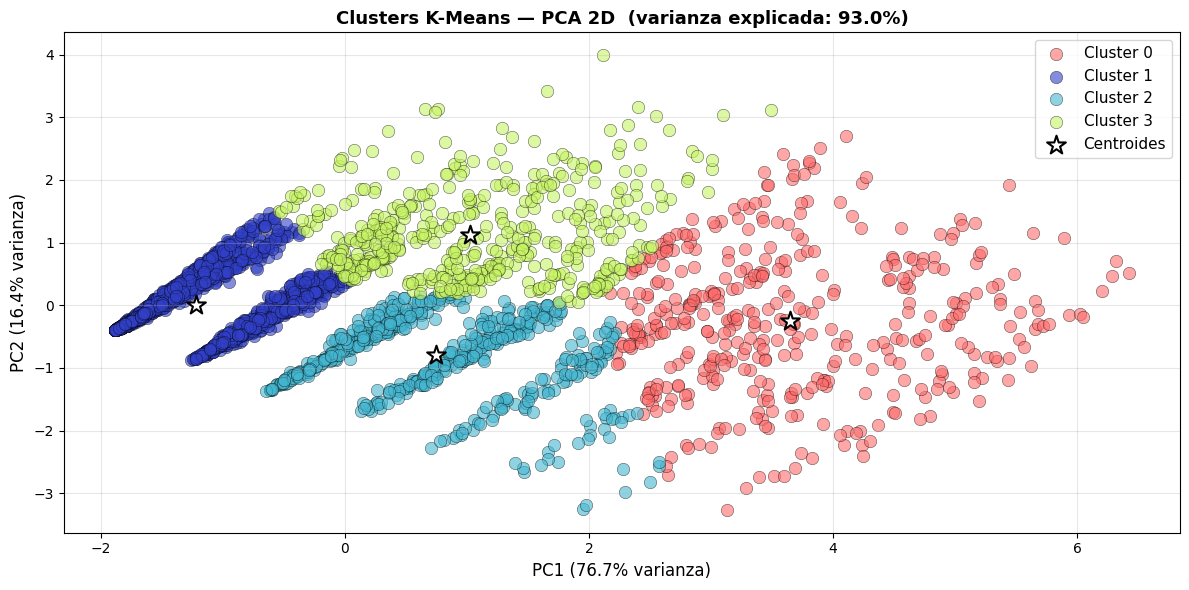

In [48]:
colors = ['#FF6B6B', "#3140C7", '#45B7D1', '#C7F464']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 6))
for cluster_id in range(k_optima):
  mask = clusters == cluster_id
  plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
    label=f'Cluster {cluster_id}',
    alpha=0.6, s=80, color=colors[cluster_id], edgecolors='black', linewidth=0.4)

centroids_pca = pca.transform(scaler.transform(cluster_profiles))
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
  marker='*', s=200, color='white', edgecolors='black', linewidth=1.5,
  label='Centroides', zorder=5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)', fontsize=12)
plt.title(f'Clusters K-Means — PCA 2D  (varianza explicada: {pca.explained_variance_ratio_.sum():.1%})',
  fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Segmentación de Clientes

Se pueden identificar 4 segmentos claves de clientes en el análisis de clustering con K-Means, cada uno con características y comportamientos de compra distintos. A continuación se describen los perfiles de cada cluster:

##### Cluster 1: Clientes Ocasionales
- Características:
  - Compras: Bajo
  - Productos distintos: Bajo
  - Gasto total: Bajo
  - Frecuencia: Bajo
- Perfil: Clientes de una sola compra o muy esporádicos sin continuidad y con poco gasto.

---

##### Cluster 3: Clientes Activos
- Características:
  - Compras: Alto
  - Productos distintos: Medio
  - Gasto total: Medio
  - Frecuencia: Medio
- Perfil: Clientes con más compras, buen gasto y diversidad de productos.

---

##### Cluster 0: Clientes Poderosos
- Características:
  - Compras: Bajo
  - Productos distintos: Alto
  - Gasto total: Alto
  - Frecuencia: Medio
- Perfil: Cliente con menos compras pero alta diversidad de productos y gasto.

---

##### Cluster 2: Clientes Premium
- Características:
  - Compras: Alto
  - Productos distintos: Alto
  - Gasto total: Alto
  - Frecuencia: Alto
- Perfil: Los clientes que más compras realizan, con mayor gasto y diversidad de productos.

---